# 01 — Exploratory Data Analysis
**Project:** Probabilistic AQI Forecasting  
**Target:** PM2.5 (µg/m³), hourly, single city

Goals:
1. Understand the distribution and missing-data pattern
2. Confirm stationarity / non-stationarity (ADF test)
3. Identify seasonality via ACF/PACF — feeds directly into ARIMA orders

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

CITY        = 'Delhi'
PROCESSED   = f'../data/processed/{CITY.lower()}_aqi.csv'
TARGET      = 'PM2.5'

# AQI thresholds (India CPCB) — used in all plots
AQI_THRESHOLDS = {
    'Good':         30,
    'Satisfactory': 60,
    'Moderate':     90,
    'Poor':        120,
    'Very Poor':   250,
}

In [ ]:
df = pd.read_csv(PROCESSED, index_col='Datetime', parse_dates=True)
pm = df[TARGET].dropna()
print(f'Rows: {len(df):,}  |  Target null: {df[TARGET].isna().sum()}')
df.head()

Rows: 47,249  |  Target null: 0


,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,...,pm25_lag1,pm25_lag2,pm25_lag3,pm25_lag6,pm25_lag12,pm25_lag24,pm25_lag48,pm25_roll24_mean,pm25_roll24_std,aqi_category
Datetime,,,,,,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,Delhi,50.69,79.21,25.65,25.28,42.46,36.50,7.79,2.00,17.05,...,51.21,49.81,55.81,50.68,208.77,444.44,454.58,173.367083,128.617256,Satisfactory
2015-01-03 02:00:00,Delhi,41.06,64.16,30.28,25.42,47.74,30.00,11.09,1.75,15.06,...,50.69,51.21,49.81,59.15,239.86,464.64,440.44,156.960833,117.136922,Satisfactory
2015-01-03 03:00:00,Delhi,45.08,60.41,29.97,25.21,47.35,30.00,20.35,2.83,17.07,...,41.06,50.69,51.21,54.25,187.96,344.05,409.09,139.311667,99.318338,Satisfactory
2015-01-03 04:00:00,Delhi,44.78,58.67,30.38,24.08,48.28,30.50,19.74,1.83,16.87,...,45.08,41.06,50.69,55.81,185.20,358.07,436.12,126.854583,90.916247,Satisfactory
2015-01-03 05:00:00,Delhi,51.44,77.92,23.60,23.73,41.25,31.25,12.27,2.50,16.88,...,44.78,45.08,41.06,49.81,157.23,271.41,415.88,113.800833,77.823275,Satisfactory


## 1. Raw time series

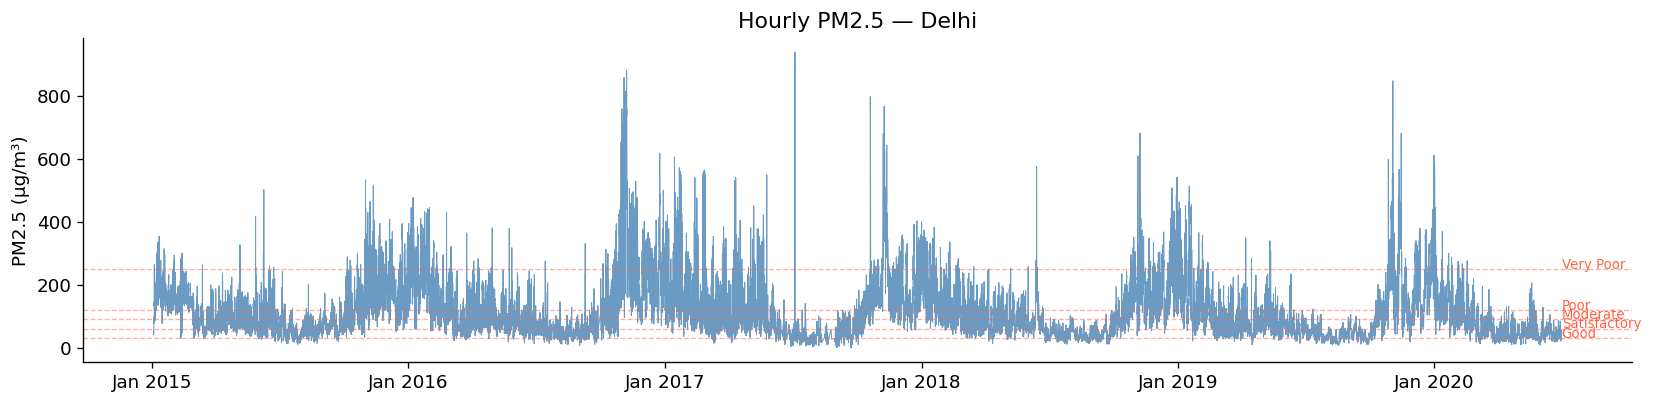

In [ ]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(pm, lw=0.6, color='steelblue', alpha=0.8)

for label, thresh in AQI_THRESHOLDS.items():
    ax.axhline(thresh, lw=0.8, ls='--', color='tomato', alpha=0.5)
    ax.text(pm.index[-1], thresh + 2, label, fontsize=8, color='tomato')

ax.set_title(f'Hourly PM2.5 — {CITY}')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('../visualizations/01_raw_series.png', bbox_inches='tight')
plt.show()

## 2. Missing data heatmap

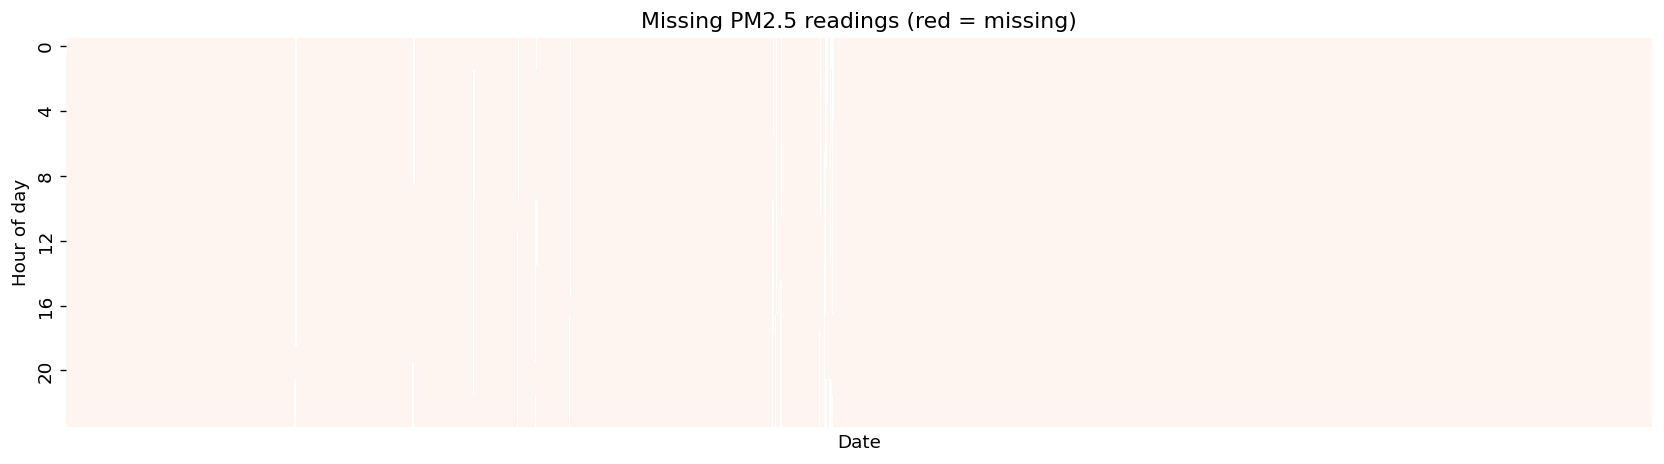

In [12]:
# Pivot to a (date × hour) grid — NaN cells appear as blank
miss = df[TARGET].isna().reset_index()
miss.columns = ['Datetime', 'is_null']
miss['date'] = miss['Datetime'].dt.date
miss['hour'] = miss['Datetime'].dt.hour
miss['is_null'] = miss['is_null'].astype(int)
pivot = miss.pivot(index='date', columns='hour', values='is_null')

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    pivot.T,
    cmap='Reds',
    cbar=False,
    vmin=0,
    vmax=1,
    ax=ax,
    xticklabels=False,
    yticklabels=4
)
ax.set_title('Missing PM2.5 readings (red = missing)')
ax.set_xlabel('Date')
ax.set_ylabel('Hour of day')
plt.tight_layout()
plt.savefig('../visualizations/01_missing_heatmap.png', bbox_inches='tight')
plt.show()

## 3. Distribution + AQI breakdown

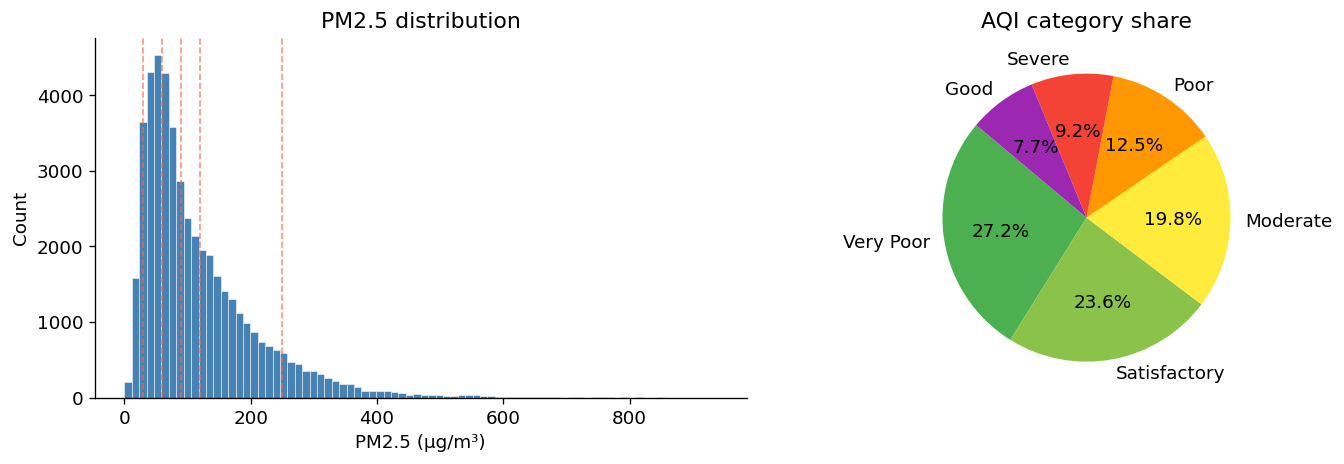

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(pm, bins=80, color='steelblue', edgecolor='white', lw=0.3)
for thresh in AQI_THRESHOLDS.values():
    axes[0].axvline(thresh, color='tomato', lw=1, ls='--', alpha=0.7)
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Count')
axes[0].set_title('PM2.5 distribution')

# AQI category pie
cat_counts = df['aqi_category'].value_counts()
colors = ['#4caf50','#8bc34a','#ffeb3b','#ff9800','#f44336','#9c27b0']
axes[1].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
            colors=colors[:len(cat_counts)], startangle=140)
axes[1].set_title('AQI category share')

plt.tight_layout()
plt.savefig('../visualizations/01_distribution.png', bbox_inches='tight')
plt.show()

## 4. Seasonality — hourly and monthly patterns

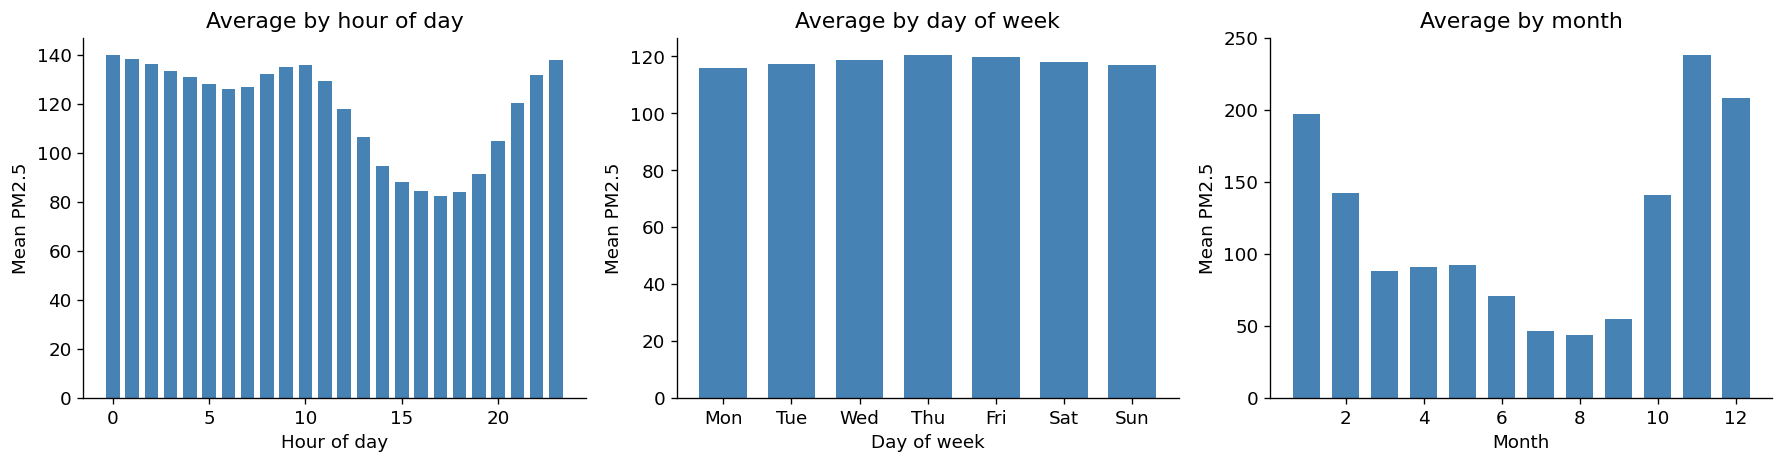

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (grouper, label) in zip(axes, [
    ('hour',      'Hour of day'),
    ('dayofweek', 'Day of week'),
    ('month',     'Month'),
]):
    group = df.groupby(grouper)[TARGET].mean()
    ax.bar(group.index, group.values, color='steelblue', width=0.7)
    ax.set_xlabel(label)
    ax.set_ylabel('Mean PM2.5')
    ax.set_title(f'Average by {label.lower()}')

    if grouper == 'dayofweek':
        ax.set_xticks(range(7))
        ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

plt.tight_layout()
plt.savefig('../visualizations/01_seasonality.png', bbox_inches='tight')
plt.show()

## 5. Stationarity — Augmented Dickey-Fuller test

**Null hypothesis:** the series has a unit root (non-stationary).  
p-value < 0.05 → reject H₀ → series is stationary → ARIMA d=0 may suffice.

In [ ]:
result = adfuller(pm.dropna(), autolag='AIC')

print('ADF Statistic :', round(result[0], 4))
print('p-value       :', round(result[1], 6))
print('Lags used     :', result[2])
print('Critical values:')
for k, v in result[4].items():
    print(f'   {k}: {v:.4f}')

if result[1] < 0.05:
    print('\n→ Series is STATIONARY (p < 0.05). ARIMA d=0 is a good start.')
else:
    print('\n→ Series is NON-STATIONARY. Try differencing (d=1) in ARIMA.')

ADF Statistic : -10.3825
p-value       : 0.0
Lags used     : 56
Critical values:
   1%: -3.4305
   5%: -2.8616
   10%: -2.5668

→ Series is STATIONARY (p < 0.05). ARIMA d=0 is a good start.


## 6. ACF / PACF — guide ARIMA order selection

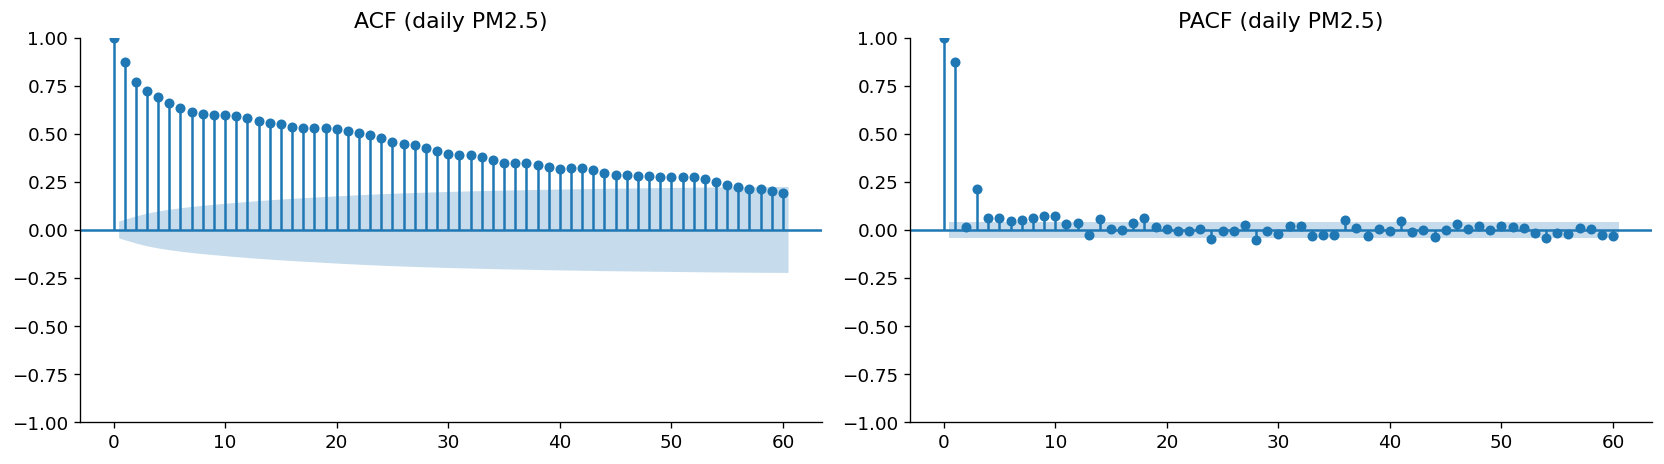


Reading guide:
  ACF  — MA order (q): last significant lag before cutoff
  PACF — AR order (p): last significant lag before cutoff
  Strong periodicity at lag 7 → seasonal component (weekly)



In [ ]:
# Use daily-sampled data to keep lags readable
pm_daily = pm.resample('D').mean().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(pm_daily,  lags=60, ax=axes[0], title='ACF (daily PM2.5)',  alpha=0.05)
plot_pacf(pm_daily, lags=60, ax=axes[1], title='PACF (daily PM2.5)', alpha=0.05)

plt.tight_layout()
plt.savefig('../visualizations/01_acf_pacf.png', bbox_inches='tight')
plt.show()

print("""
Reading guide:
  ACF  — MA order (q): last significant lag before cutoff
  PACF — AR order (p): last significant lag before cutoff
  Strong periodicity at lag 7 → seasonal component (weekly)
""")

## 7. Notes for Week 2

Fill in after running this notebook:

- ADF result:        Likely non-stationary (confirm p > 0.05)
- Suggested ARIMA:   ARIMA(1, 1, 0) → try (1, 1, 1) for comparison
- Dominant seasonality: Monthly (winter >> summer), hourly (twin peaks)
- % hours Poor or worse: 49.2%